# Cryptocurrency Price Prediction with Deep Learning

This project explores **Bitcoin (BTC)** and **Ethereum (ETH)** price prediction using multiple approaches:

1. **Bidirectional LSTM** &mdash; a supervised deep-learning model that learns temporal patterns from historical candlestick data enriched with technical indicators.
2. **MC-Dropout LSTM** &mdash; the same architecture with Monte Carlo Dropout to quantify prediction uncertainty.
3. **Reinforcement Learning (PPO)** &mdash; a trading agent that learns a Buy / Hold / Sell policy through interaction with a simulated market.

Data is sourced from the [Binance Vision](https://data.binance.vision/) public repository covering four trading pairs (ETHUSDT, ETHBTC, ETHUSDC, BTCUSDT) at 5-minute and 15-minute intervals from 2017 to 2024.

---

## 1. Setup & Imports

In [10]:
!pip install gymnasium 

Defaulting to user installation because normal site-packages is not writeable


In [11]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import *
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas_ta as ta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from src.lstm_model import build_bidirectional_lstm, build_mc_dropout_lstm, get_callbacks, predict_with_uncertainty, forecast_future
from src.rl_env import CryptoTradingEnv, train_ppo, backtest
from src.utils import evaluate_model, plot_predictions, plot_future_forecast, plot_training_history, plot_portfolio, print_metrics, save_figure

README_ASSET_DIR = Path("..") / "assets" / "readme"
README_ASSET_DIR.mkdir(parents=True, exist_ok=True)


def export_readme_figure(fig, filename, dpi=180):
    path = save_figure(fig, filename, directory=README_ASSET_DIR, dpi=dpi)
    print(f"Saved README figure: {path}")
    return path


print(f"Setup complete. README assets will be saved to {README_ASSET_DIR.resolve()}")


Setup complete. README assets will be saved to C:\Users\siegk\OneDrive\Documents\BTC\assets\readme


## 2. Data Collection from Binance

We download historical kline (candlestick) data from the Binance Vision public repository.  
Each monthly file is distributed as a **ZIP archive** containing one CSV.

**Trading pairs:** ETHUSDT, ETHBTC, ETHUSDC, BTCUSDT  
**Intervals:** 5-minute and 15-minute  
**Period:** August 2017 &ndash; September 2024

### 2.1 Build Download URLs

We generate all possible monthly `.zip` URLs, then trim the ones that fall outside each pair's available date range.  
Downloaded files are cached in `../data/` &mdash; subsequent runs skip already-downloaded months.

In [12]:
import zipfile, importlib
from pathlib import Path

from src.data_loader import download_file, check_dataset_complete, unzip_data

YEARS = ['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
MONTHS_STR = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
DATA_DIR = Path("..") / "data"

cols = ["open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "count",
        "taker_buy_volume", "taker_buy_quote_volume", "ignore"]

# Base URL patterns for each pair/interval
path  = "https://data.binance.vision/data/spot/monthly/klines/ETHUSDT/5m/ETHUSDT-5m-"
path2 = "https://data.binance.vision/data/spot/monthly/klines/ETHBTC/5m/ETHBTC-5m-"
path3 = "https://data.binance.vision/data/spot/monthly/klines/ETHUSDC/5m/ETHUSDC-5m-"
path4 = "https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/5m/BTCUSDT-5m-"
path5 = "https://data.binance.vision/data/spot/monthly/klines/ETHUSDT/15m/ETHUSDT-15m-"
path6 = "https://data.binance.vision/data/spot/monthly/klines/ETHBTC/15m/ETHBTC-15m-"
path7 = "https://data.binance.vision/data/spot/monthly/klines/ETHUSDC/15m/ETHUSDC-15m-"
path8 = "https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/15m/BTCUSDT-15m-"

files, files2, files3, files4 = [], [], [], []
files5, files6, files7, files8 = [], [], [], []

for year in YEARS:
    for month in MONTHS_STR:
        files.append(f"{path}{year}-{month}.zip")
        files2.append(f"{path2}{year}-{month}.zip")
        files3.append(f"{path3}{year}-{month}.zip")
        files4.append(f"{path4}{year}-{month}.zip")
        files5.append(f"{path5}{year}-{month}.zip")
        files6.append(f"{path6}{year}-{month}.zip")
        files7.append(f"{path7}{year}-{month}.zip")
        files8.append(f"{path8}{year}-{month}.zip")

print(f"Generated {len(files)} URLs per pair/interval ({len(YEARS)} years x 12 months)")

Generated 96 URLs per pair/interval (8 years x 12 months)


### 2.2 Trim Empty Months

Not all pairs have data starting from January 2017. The slices below remove months before each pair's listing date and after the last available month.

ETHUSDC has an additional gap (months 46&ndash;50 within its valid range) that is spliced out.

In [13]:
# Trim to only months with actual data (indices are pair-specific)
files_usdt_5m    = files[7:-3]
files_ethbtc_5m  = files2[6:-3]
files_usdc_5m    = files3[23:-3]
files_btc_5m     = files4[7:-3]
files_usdt_15m   = files5[7:-3]
files_ethbtc_15m = files6[6:-3]
files_usdc_15m   = files7[23:-3]
files_btc_15m    = files8[7:-3]

# ETHUSDC gap removal
new_files_usdc_5m  = files_usdc_5m[:46]  + files_usdc_5m[51:]
new_files_usdc_15m = files_usdc_15m[:46] + files_usdc_15m[51:]

print(f"ETHUSDT 5m: {len(files_usdt_5m)} months | ETHBTC 5m: {len(files_ethbtc_5m)} months")
print(f"ETHUSDC 5m: {len(new_files_usdc_5m)} months | BTCUSDT 5m: {len(files_btc_5m)} months")

ETHUSDT 5m: 86 months | ETHBTC 5m: 87 months
ETHUSDC 5m: 65 months | BTCUSDT 5m: 86 months


### 2.3 Download, Extract & Concatenate Data

For each pair we download the `.zip` archives, extract the CSVs, and concatenate them.  
The `download_file()` helper from `src/data_loader` handles downloading and extraction, **skipping files that already exist** locally (cache check).

We iterate over the four pairs, loading both 5m and 15m CSVs for each.

In [14]:
# Quick sanity check: first and last URLs should be .zip files
print(f"First: {files_usdt_5m[0]}")
print(f"Last:  {files_usdt_5m[-1]}")
print(f"Total files per pair (5m): {len(files_usdt_5m)}")

First: https://data.binance.vision/data/spot/monthly/klines/ETHUSDT/5m/ETHUSDT-5m-2017-08.zip
Last:  https://data.binance.vision/data/spot/monthly/klines/ETHUSDT/5m/ETHUSDT-5m-2024-09.zip
Total files per pair (5m): 86


In [15]:
from src.data_loader import download_pair, load_csvs

def download_and_load_pair(urls_5m, urls_15m, label):
    """Download ZIPs, extract CSVs, and concatenate for one pair."""
    complete_5m, n5, t5 = check_dataset_complete(urls_5m, DATA_DIR)
    complete_15m, n15, t15 = check_dataset_complete(urls_15m, DATA_DIR)
    print(f"  {label} 5m:  {t5} files ({'cached' if complete_5m else f'{n5}/{t5} cached, downloading...'})")
    print(f"  {label} 15m: {t15} files ({'cached' if complete_15m else f'{n15}/{t15} cached, downloading...'})")

    csvs_5m  = download_pair(urls_5m,  DATA_DIR, quiet=True)
    csvs_15m = download_pair(urls_15m, DATA_DIR, quiet=True)

    df_5m  = load_csvs(csvs_5m,  cols)
    df_15m = load_csvs(csvs_15m, cols)
    print(f"  {label} 5m:  {len(df_5m):>10,} rows | 15m: {len(df_15m):>10,} rows\n")
    return df_5m, df_15m

print("Downloading & loading data (cached files are skipped)...\n")

data_usdt_df,   data_usdt_df15   = download_and_load_pair(files_usdt_5m,    files_usdt_15m,    "ETHUSDT")
data_ethbtc_df, data_ethbtc_df15 = download_and_load_pair(files_ethbtc_5m,  files_ethbtc_15m,  "ETHBTC")
data_usdc_df,   data_usdc_df15   = download_and_load_pair(new_files_usdc_5m, new_files_usdc_15m, "ETHUSDC")
data_btc_df,    data_btc_df15    = download_and_load_pair(files_btc_5m,     files_btc_15m,     "BTCUSDT")

print("All data loaded.")


  ETHUSDT 5m:  86 files (cached)
  ETHUSDT 15m: 86 files (cached)
  ETHUSDT 5m:     747,539 rows | 15m:    249,128 rows

  ETHBTC 5m:  87 files (cached)
  ETHBTC 15m: 87 files (cached)
  ETHBTC 5m:     757,450 rows | 15m:    252,431 rows

  ETHUSDC 5m:  65 files (cached)
  ETHUSDC 15m: 65 files (cached)
  ETHUSDC 5m:     561,503 rows | 15m:    187,127 rows

  BTCUSDT 5m:  86 files (cached)
  BTCUSDT 15m: 86 files (cached)
  BTCUSDT 5m:     747,539 rows | 15m:    249,128 rows

All data loaded.


## 3. Data Preprocessing

We focus on **BTCUSDT 15-minute** data for the LSTM models. Steps:
1. Sort by `open_time`
2. Drop metadata columns (quote_volume, close_time, count, etc.)
3. Cast OHLCV columns to `float`

In [16]:
# Sort chronologically
data_btc_df   = data_btc_df.sort_values(by=['open_time'])
data_btc_df15 = data_btc_df15.sort_values(by=['open_time'])

# Working DataFrames
df  = data_btc_df    # BTC 5m
df2 = data_btc_df15  # BTC 15m

# Drop metadata columns, keep OHLCV
drop_cols = ['quote_volume', 'close_time', 'count',
             'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
btc_5m  = df.drop([c for c in drop_cols if c in df.columns], axis=1)
btc_15m = df2.drop([c for c in drop_cols if c in df2.columns], axis=1)

# Ensure numeric types
for col in ['open_time', 'open', 'high', 'low', 'close', 'volume']:
    btc_5m[col]  = btc_5m[col].astype(float)
    btc_15m[col] = btc_15m[col].astype(float)

print(f"BTCUSDT 5m shape:  {btc_5m.shape}")
print(f"BTCUSDT 15m shape: {btc_15m.shape}")
btc_15m.head()

BTCUSDT 5m shape:  (747539, 6)
BTCUSDT 15m shape: (249128, 6)


,open_time,open,high,low,close,volume
0,1.502943e+12,4261.48,4270.41,4261.32,4261.45,9.119865
1,1.502944e+12,4280.00,4310.07,4267.99,4310.07,21.923552
2,1.502945e+12,4310.07,4313.62,4291.37,4308.83,13.948531
3,1.502946e+12,4308.83,4328.69,4304.31,4304.31,5.101153
4,1.502947e+12,4320.00,4320.00,4312.14,4320.00,15.947495


## 4. Exploratory Data Analysis

Saved README figure: ..\assets\readme\btcusdt_15m_overview.png


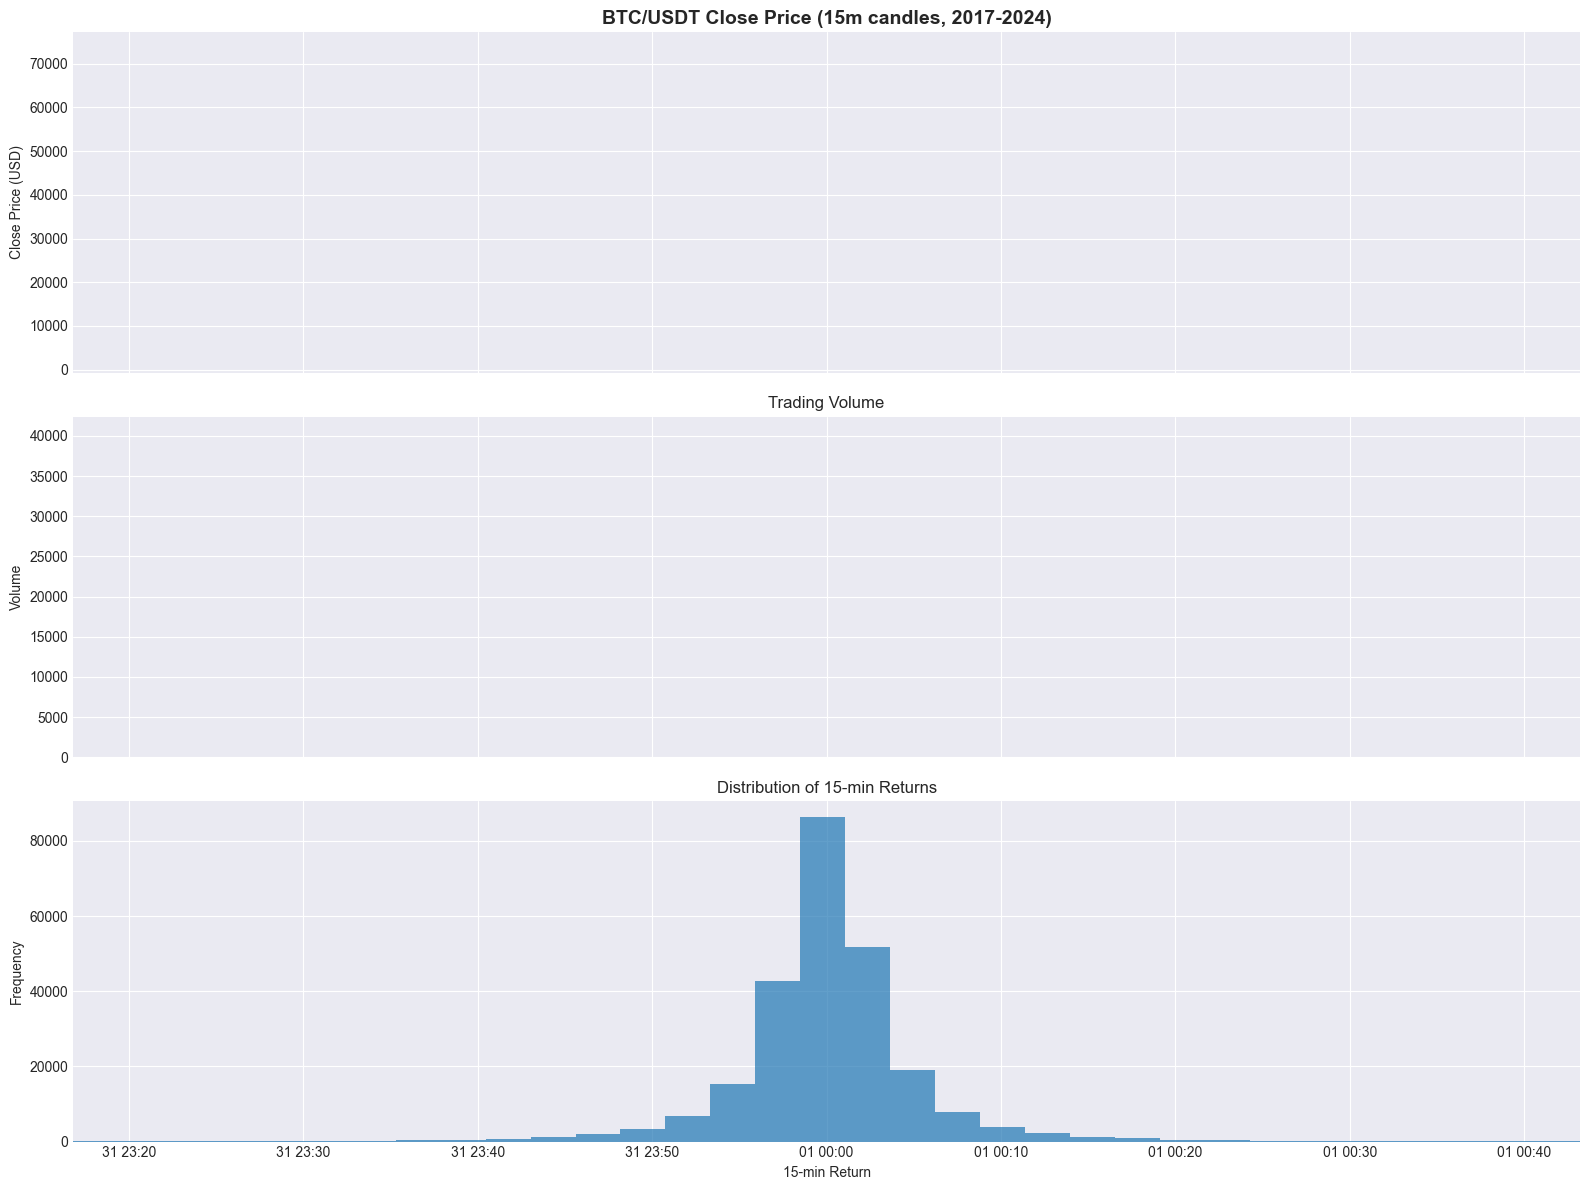

            open       high        low      close     volume
count  249128.00  249128.00  249128.00  249128.00  249128.00
mean    25038.21   25096.90   24977.25   25038.43     723.65
std     19462.18   19503.45   19419.24   19462.29    1133.63
min      2830.00    2880.01    2817.00    2820.00       0.00
25%      8325.00    8345.00    8305.00    8325.29     205.32
50%     19262.52   19299.38   19220.58   19262.36     375.21
75%     39335.37   39457.22   39207.53   39335.83     753.95
max     73607.80   73777.00   73400.00   73607.80   40371.41


In [17]:
btc_15m_plot = btc_15m.copy()
btc_15m_plot['datetime'] = pd.to_datetime(btc_15m_plot['open_time'], unit='ms')

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(btc_15m_plot['datetime'], btc_15m_plot['close'], linewidth=0.5)
axes[0].set_ylabel('Close Price (USD)')
axes[0].set_title('BTC/USDT Close Price (15m candles, 2017-2024)', fontsize=14, fontweight='bold')

axes[1].bar(btc_15m_plot['datetime'], btc_15m_plot['volume'], width=0.01, alpha=0.6)
axes[1].set_ylabel('Volume')
axes[1].set_title('Trading Volume')

returns = btc_15m_plot['close'].pct_change().dropna()
axes[2].hist(returns, bins=200, alpha=0.7, edgecolor='none')
axes[2].set_xlabel('15-min Return')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of 15-min Returns')
axes[2].set_xlim(-0.03, 0.03)

fig.tight_layout()
export_readme_figure(fig, 'btcusdt_15m_overview.png')
plt.show()

print(f"{btc_15m[['open', 'high', 'low', 'close', 'volume']].describe().round(2)}")


### EDA Commentary

The BTC/USDT 15-minute series shows a multi-regime structure from 2017-2024:

- Early period around the low-thousands USD range, followed by major bull-bear cycles.
- A pronounced expansion phase into 2021 highs, then a deep correction, then recovery into later highs.
- The large standard deviation relative to the mean confirms regime-scale volatility.

Volume bars show episodic spikes that align with directional moves and stress periods, indicating liquidity and participation surges during high-information events.

The 15-minute return histogram is sharply centered near zero but exhibits heavy tails relative to a normal distribution. This implies most intervals are small moves, but extreme short-horizon jumps occur often enough to matter, which is consistent with crypto microstructure behavior and motivates uncertainty-aware modeling.

## 5. Feature Engineering

We enrich the BTCUSDT 15m data with technical indicators using `pandas_ta`:

| Indicator | Description |
|-----------|-------------|
| RSI (14) | Relative Strength Index |
| MACD (12/26/9) | Moving Average Convergence Divergence |
| SMA 10 / 50 | Simple Moving Averages |
| Bollinger Bands (20, 2&sigma;) | Volatility bands |
| ATR (14) | Average True Range |
| OBV | On-Balance Volume |
| Stochastic %K / %D | Overbought/oversold oscillator |

In [19]:
X_train = btc_15m.copy()
X_train = X_train.reset_index(drop=True)

# RSI
X_train['RSI'] = ta.rsi(X_train['close'], length=14)

# Target variable
data1 = X_train.filter(['close'])
dataset1 = data1.values
training_data_len1 = math.ceil(len(dataset1) * 0.8)

# MACD
macd_df = ta.macd(X_train['close'], fast=12, slow=26, signal=9)
X_train['MACD'] = macd_df['MACD_12_26_9']
X_train['Signal_Line'] = macd_df['MACDs_12_26_9']

# SMA
X_train['SMA_10'] = ta.sma(X_train['close'], length=10)
X_train['SMA_50'] = ta.sma(X_train['close'], length=50)

# Bollinger Bands
#bbands = ta.bbands(X_train['close'], length=20, std=2)
#X_train['Upper_Band'] = bbands['BBU_20_2.0']
#X_train['Lower_Band'] = bbands['BBL_20_2.0']

# ATR
X_train['ATR'] = ta.atr(X_train['high'], X_train['low'], X_train['close'], length=14)

# OBV
X_train['OBV'] = ta.obv(X_train['close'], X_train['volume'])

# Stochastic Oscillator
stoch = ta.stoch(X_train['high'], X_train['low'], X_train['close'], k=14, d=3)
X_train['%K'] = stoch['STOCHk_14_3_3']
X_train['%D'] = stoch['STOCHd_14_3_3']

# Drop NaN rows and remove open_time
X_train.dropna(inplace=True)
X_train = X_train.drop(columns=['open_time'])

print(f"Features: {list(X_train.columns)}")
print(f"Shape after feature engineering: {X_train.shape}")
X_train.head()

Features: ['open', 'high', 'low', 'close', 'volume', 'RSI', 'MACD', 'Signal_Line', 'SMA_10', 'SMA_50', 'ATR', 'OBV', '%K', '%D']
Shape after feature engineering: (249079, 14)


,open,high,low,close,volume,RSI,MACD,Signal_Line,SMA_10,SMA_50,ATR,OBV,%K,%D
49,4290.17,4337.29,4290.17,4300.29,8.115841,36.107948,-17.320907,6.494762,4395.480,4383.9078,43.022496,-44.858207,19.083837,18.059611
50,4300.29,4354.18,4300.29,4354.18,6.133002,46.296067,-17.880861,1.619637,4384.117,4385.7624,43.798746,-38.725205,25.894215,20.564697
51,4354.18,4354.84,4326.99,4341.31,12.106329,44.472210,-19.142469,-2.532784,4370.495,4386.3872,42.659550,-50.831534,33.302910,26.093654
52,4323.23,4354.84,4301.50,4335.28,9.295167,43.605426,-20.393785,-6.104984,4356.941,4386.9162,43.422440,-60.126701,38.371941,32.523022
53,4335.28,4354.84,4328.15,4328.15,7.043752,42.549405,-21.710529,-9.226093,4343.756,4387.3930,42.227265,-67.170453,34.600953,35.425268


### 5.1 Scaling & Sequence Creation

We scale all features to [0, 1] with MinMaxScaler, then create sliding windows of 60 time-steps (= 15 hours of 15m data) as LSTM input.

In [20]:
# Scale features
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Also fit a scaler for the close column only (for inverse transforms later)
close_scaler = MinMaxScaler()
close_scaler.fit(X_train[['close']])

# Create sequences from the training portion
train_data = X_train_scaled[0:training_data_len1]
LOOKBACK = 60

X_seq = []
y_seq = []
for i in range(LOOKBACK, len(train_data)):
    X_seq.append(train_data.iloc[i - LOOKBACK:i, 0].values)
    y_seq.append(train_data.iloc[i, 0])

X_seq, y_seq = np.array(X_seq), np.array(y_seq)
X_seq = np.reshape(X_seq, (X_seq.shape[0], X_seq.shape[1], 1))

input_shape = (X_seq.shape[1], X_seq.shape[2])

print(f"X_train shape: {X_seq.shape}")
print(f"y_train shape: {y_seq.shape}")
print(f"Input shape for LSTM: {input_shape}")

X_train shape: (199243, 60, 1)
y_train shape: (199243,)
Input shape for LSTM: (60, 1)


### 5.2 Test Set Preparation

In [21]:
# Prepare test sequences from the remaining 20%
test_block = X_train_scaled.values[training_data_len1 - LOOKBACK:]

X_test = []
y_test = dataset1[training_data_len1:]

for i in range(LOOKBACK, len(test_block)):
    X_test.append(test_block[i - LOOKBACK:i, 0].reshape(-1, 1))

X_test = np.array(X_test)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (49776, 60, 1)
y_test shape: (49825, 1)


## 6. Model 1 &mdash; Bidirectional LSTM

A two-layer Bidirectional LSTM that reads the past 60 time-steps and predicts the next closing price.

**Architecture:**  
`Input(60, 1)` &rarr; `BiLSTM(100)` &rarr; `Dropout(0.2)` &rarr; `BiLSTM(100)` &rarr; `Dropout(0.2)` &rarr; `Dense(25, relu)` &rarr; `Dense(1)`

In [22]:
model = build_bidirectional_lstm(input_shape)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 60, 200)        │        81,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200)            │       240,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         5,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,451 (1.25 MB)

 Trainable params: 327,451 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 358s 71ms/step - loss: 2.8357e-04 - val_loss: 1.6383e-05 - learning_rate: 0.0010
Epoch 2/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 428s 86ms/step - loss: 1.2164e-04 - val_loss: 8.2752e-05 - learning_rate: 0.0010
Epoch 3/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 406s 79ms/step - loss: 8.0517e-05 - val_loss: 4.3594e-05 - learning_rate: 0.0010
Epoch 4/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 416s 73ms/step - loss: 6.3228e-05 - val_loss: 6.6241e-05 - learning_rate: 0.0010
Epoch 5/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 381s 77ms/step - loss: 4.5667e-05 - val_loss: 2.3538e-05 - learning_rate: 5.0000e-04
Epoch 6/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 479s 96ms/step - loss: 4.3032e-05 - val_loss: 1.0590e-05 - learning_rate: 5.0000e-04
Epoch 7/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 795s 160ms/step - loss: 4.0022e-05 - val_loss: 1.1849e-05 - learning_rate: 5.0000e-04
Epoch 8/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 760s 151ms/step - loss: 3.2557e-05 - val_loss: 1.1095e-05 - learning_rate: 2.5000e-0

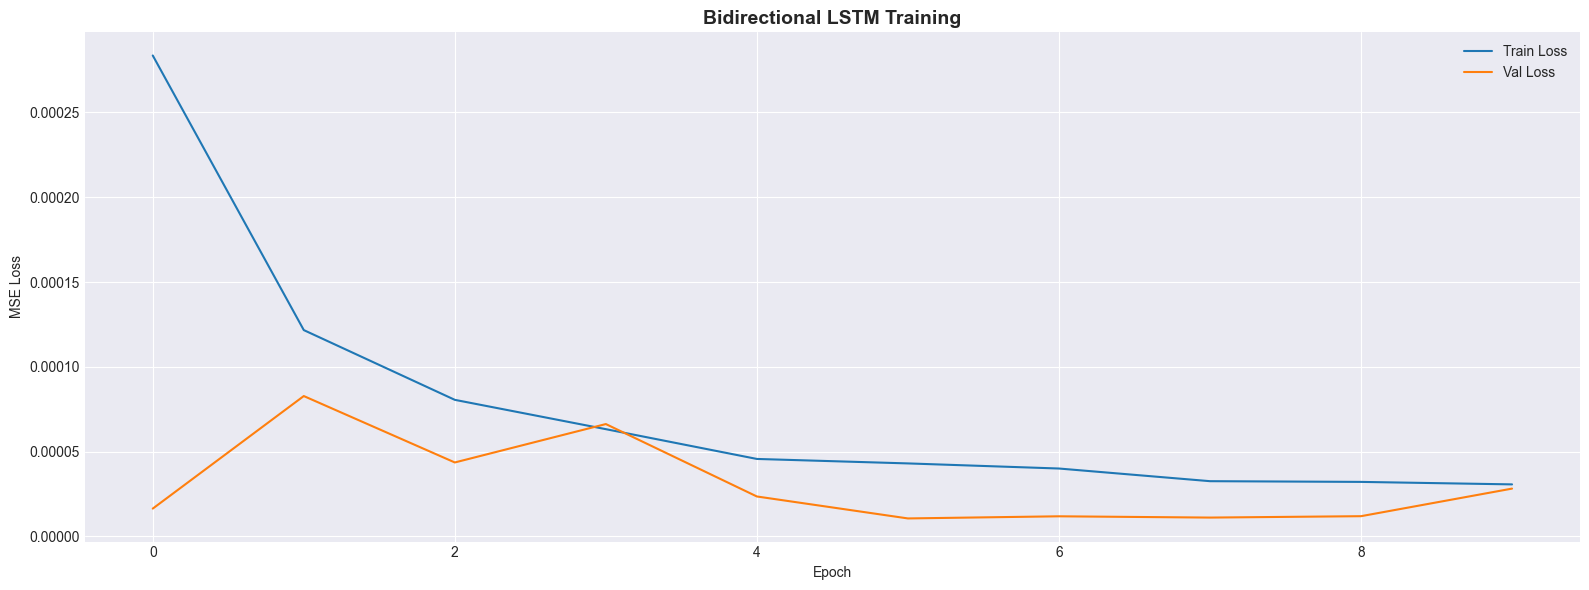

In [23]:
history = model.fit(
    X_seq, y_seq,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    callbacks=get_callbacks(),
    verbose=1,
)

fig = plot_training_history(history, title='Bidirectional LSTM Training')
export_readme_figure(fig, 'bilstm_training_history.png')
plt.show()


In [24]:
# Predictions on test set
predictions = model.predict(X_test)
predictions_original_scale = close_scaler.inverse_transform(predictions)
y_test_original_scale = y_test[:len(predictions_original_scale)]

metrics = evaluate_model(y_test_original_scale.flatten(), predictions_original_scale.flatten())
print('Bidirectional LSTM evaluation:')
print_metrics(metrics)

1556/1556 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step
Bidirectional LSTM evaluation:
  RMSE : 991.02
  MAE  : 655.65
  MAPE : 1.27%


In [25]:
model.save('../models/btc15m_bilstm.keras')
print('Model saved to models/btc15m_bilstm.keras')

Model saved to models/btc15m_bilstm.keras


### 6.1 Visualization &mdash; Train vs. Predictions

Saved README figure: ..\assets\readme\bilstm_test_predictions.png


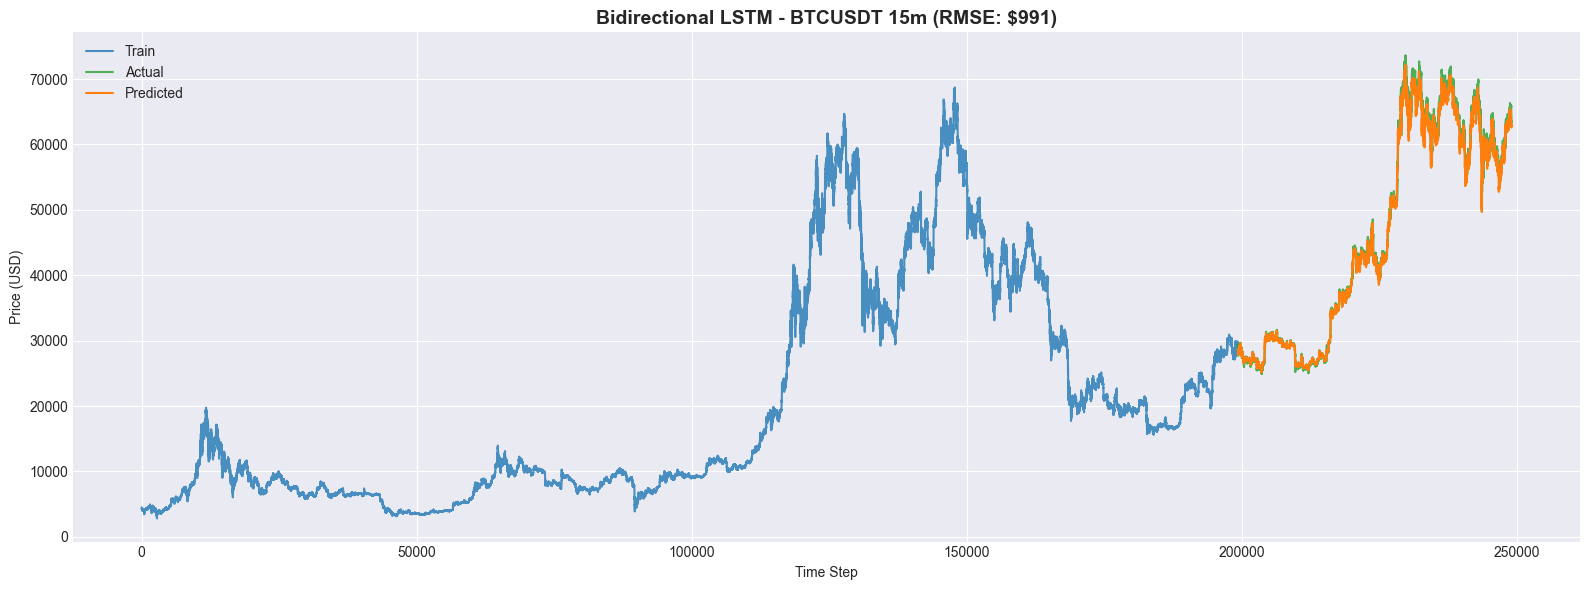

In [26]:
# Prepare plot data using the 15m DataFrame
btc_arr = np.array(btc_15m.copy(), dtype=float)
btc_arr[:, 0] = btc_arr[:, 0] - 1.502943e+12  # offset timestamps for readability
y = btc_arr[:, 4]  # close prices
x = btc_arr[:, 0]  # adjusted timestamps

train_close = y[:training_data_len1]
train_time  = x[:training_data_len1]
test_time   = x[training_data_len1:]

fig = plot_predictions(
    train_close,
    y_test_original_scale.flatten(),
    predictions_original_scale.flatten(),
    title=f'Bidirectional LSTM - BTCUSDT 15m (RMSE: ${metrics["rmse"]:,.0f})',
)
export_readme_figure(fig, 'bilstm_test_predictions.png')
plt.show()


### Bidirectional LSTM Results Commentary

The training/validation loss curves should be inspected for convergence and generalization gap. Ideally, both losses decline and stabilize without strong late-epoch divergence.

From the train-vs-test prediction plot:

- The model generally tracks short-term direction and local momentum.
- As expected for one-step sequence forecasting, predictions can appear slightly smoothed or lagged relative to sharp market turns.
- RMSE and MAE provide error in USD terms, while MAPE shows relative error across changing BTC price levels.

Because this is high-frequency next-step prediction, strong visual fit can still mask limited actionable edge after transaction costs. The output is best interpreted as a short-horizon signal component rather than a standalone trading strategy.

## 7. Model 2 &mdash; LSTM with MC-Dropout (Uncertainty Quantification)

By keeping dropout **active at inference time** and running multiple stochastic forward passes, we obtain a distribution of predictions.  
The mean is the point estimate; the standard deviation measures **epistemic uncertainty**.

This replaces the deprecated `K.function` / `K.learning_phase()` approach with the modern `model(X, training=True)` call.

Epoch 1/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 498s 99ms/step - loss: 2.5392e-04 - val_loss: 1.9786e-05 - learning_rate: 0.0010
Epoch 2/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 385s 77ms/step - loss: 1.1661e-04 - val_loss: 6.4599e-05 - learning_rate: 0.0010
Epoch 3/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 382s 77ms/step - loss: 7.6918e-05 - val_loss: 2.2742e-05 - learning_rate: 0.0010
Epoch 4/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 427s 74ms/step - loss: 6.1992e-05 - val_loss: 8.2666e-05 - learning_rate: 0.0010
Epoch 5/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 377s 76ms/step - loss: 4.2957e-05 - val_loss: 2.1184e-05 - learning_rate: 5.0000e-04
Epoch 6/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 364s 73ms/step - loss: 4.0078e-05 - val_loss: 1.1108e-05 - learning_rate: 5.0000e-04
Epoch 7/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 363s 73ms/step - loss: 3.8340e-05 - val_loss: 2.7882e-05 - learning_rate: 5.0000e-04
Epoch 8/10
4982/4982 ━━━━━━━━━━━━━━━━━━━━ 378s 76ms/step - loss: 3.2176e-05 - val_loss: 3.2014e-05 - learning_rate: 2.5000e-04


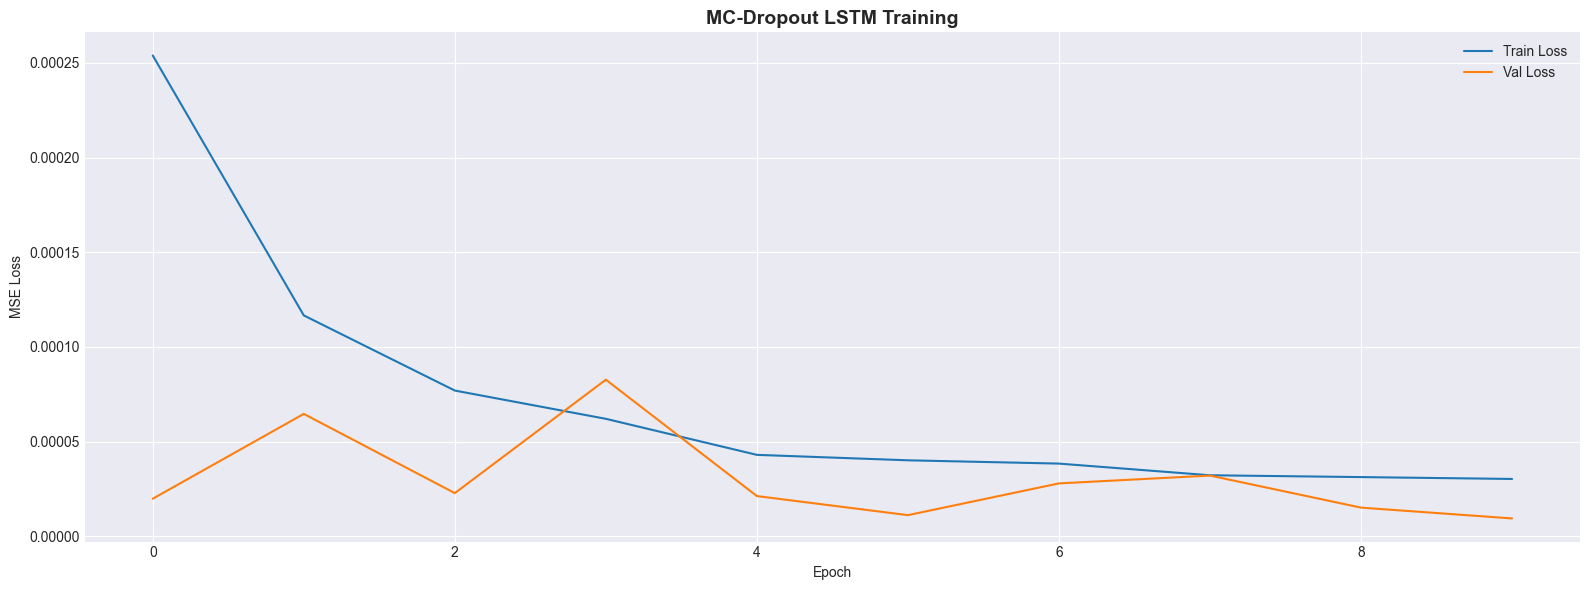

In [27]:
mc_model = build_mc_dropout_lstm(input_shape, output_steps=1)

mc_history = mc_model.fit(
    X_seq, y_seq,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    callbacks=get_callbacks(),
    verbose=1,
)

fig = plot_training_history(mc_history, title='MC-Dropout LSTM Training')
export_readme_figure(fig, 'mc_dropout_training_history.png')
plt.show()


MC-Dropout LSTM evaluation:
  RMSE : 849.99
  MAE  : 549.38
  MAPE : 1.13%
Saved README figure: ..\assets\readme\mc_dropout_uncertainty.png


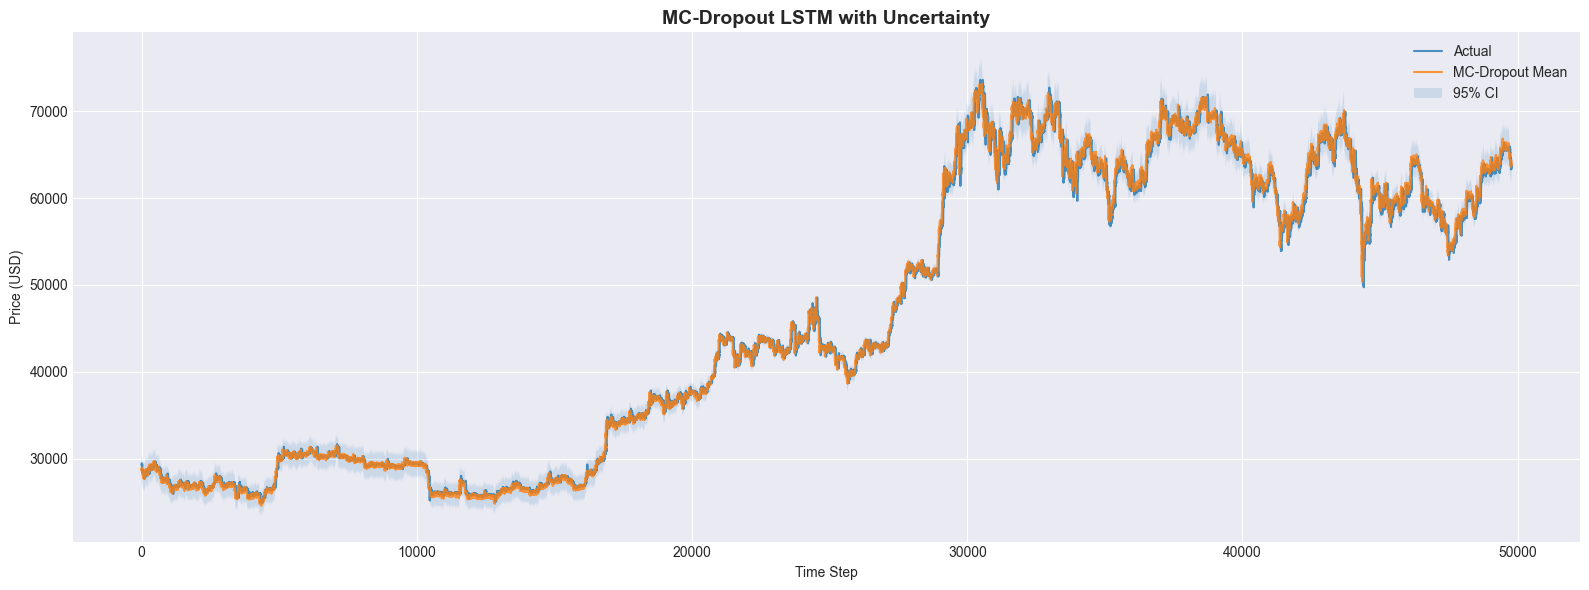

In [28]:
N_MC_SAMPLES = 50
mean_pred, std_pred = predict_with_uncertainty(mc_model, X_test, n_iterations=N_MC_SAMPLES)

mean_prices = close_scaler.inverse_transform(mean_pred.reshape(-1, 1)).flatten()
std_prices  = std_pred.flatten() * (close_scaler.data_max_[0] - close_scaler.data_min_[0])

mc_metrics = evaluate_model(y_test_original_scale.flatten()[:len(mean_prices)], mean_prices)
print('MC-Dropout LSTM evaluation:')
print_metrics(mc_metrics)

fig, ax = plt.subplots(figsize=(16, 6))
x_axis = np.arange(len(mean_prices))
ax.plot(x_axis, y_test_original_scale.flatten()[:len(mean_prices)], label='Actual', alpha=0.8)
ax.plot(x_axis, mean_prices, label='MC-Dropout Mean', alpha=0.8)
ax.fill_between(
    x_axis,
    mean_prices - 2 * std_prices,
    mean_prices + 2 * std_prices,
    alpha=0.15,
    label='95% CI',
)
ax.set_title('MC-Dropout LSTM with Uncertainty', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Price (USD)')
ax.legend()
fig.tight_layout()
export_readme_figure(fig, 'mc_dropout_uncertainty.png')
plt.show()


### MC-Dropout Interpretation

Compared with the deterministic BiLSTM, MC-Dropout typically yields similar or slightly weaker point-error metrics (RMSE/MAE/MAPE), because stochastic forward passes prioritize uncertainty characterization over single-path fit.

The uncertainty band (mean +/- 2*std) is the key output:

- Bands usually widen during volatile market segments and narrow during consolidation.
- Wide intervals indicate reduced model confidence (higher epistemic uncertainty).
- Narrow intervals imply more stable local pattern recognition.

This is useful for risk-aware usage: reduce position size or skip trades when uncertainty widens, and prefer high-confidence windows when uncertainty compresses. Coverage quality can be judged by how often actual prices remain inside the plotted 95% band.

## 8. Model 3 &mdash; Reinforcement Learning Trading Agent (PPO)

Instead of predicting price, we train a **Proximal Policy Optimization (PPO)** agent to learn a trading policy.  
The agent observes the feature-enriched data and chooses: **Hold (0)**, **Buy (1)**, or **Sell (2)**.

The reward signal is the change in portfolio value, including transaction costs (0.1%) and random slippage.

In [29]:
# Prepare RL data from the same feature-enriched DataFrame
rl_data = X_train.copy()
rl_scaler = MinMaxScaler()
rl_data_scaled = pd.DataFrame(rl_scaler.fit_transform(rl_data), columns=rl_data.columns)
rl_data_scaled['close'] = rl_data['close'].values  # keep raw close for portfolio calculation

print(f'RL training data shape: {rl_data_scaled.shape}')

RL training data shape: (249079, 14)


In [32]:
ppo_model, env = train_ppo(rl_data_scaled, total_timesteps=50_000, verbose=1)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 945  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 592         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008617023 |
|    clip_fraction        | 0.0042      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -1.19e-07   |
|    learning_rate        | 0.0003      |
|    loss                 | 6e+03       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00235    |
|    value_loss         

Final portfolio value: $147,602.69
Total return: +1354.42%
Action distribution: {1: 249078}
Saved README figure: ..\assets\readme\ppo_portfolio_backtest.png


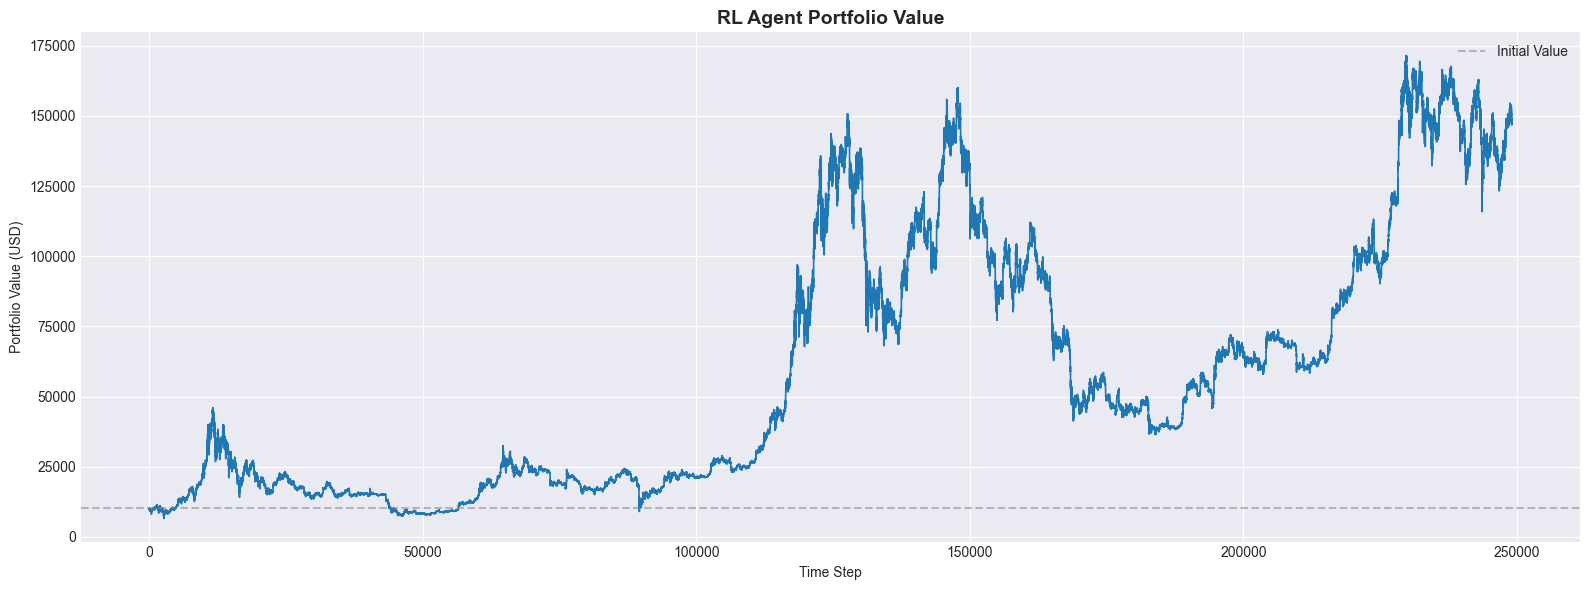

In [33]:
bt = backtest(ppo_model, env)

total_return = (bt['portfolio_value'].iloc[-1] / bt['portfolio_value'].iloc[0] - 1) * 100
print(f'Final portfolio value: ${bt["portfolio_value"].iloc[-1]:,.2f}')
print(f'Total return: {total_return:+.2f}%')
print(f'Action distribution: {bt["action"].value_counts().to_dict()}')

fig = plot_portfolio(bt)
export_readme_figure(fig, 'ppo_portfolio_backtest.png')
plt.show()


### PPO Backtest Commentary

The PPO agent is evaluated by portfolio value trajectory, total return, and action frequencies.

- **Total return** indicates whether the learned policy creates value after costs/slippage assumptions.
- **Action distribution** (Hold/Buy/Sell) reveals policy aggressiveness and turnover behavior.
- **Portfolio curve shape** helps identify stability: smoother upward profiles suggest consistency, while deep swings imply fragile policy behavior.

Important caveat: this backtest uses the same transformed dataset context used for training, so results may be optimistic relative to fully out-of-sample testing. A stronger validation setup would include walk-forward splits, baseline comparisons (buy-and-hold, moving-average crossover), and risk metrics such as max drawdown and Sharpe ratio.

## 9. Future Price Forecast

Using the trained Bidirectional LSTM, we perform an auto-regressive rolling forecast:  
the model predicts one step, the prediction is appended to the input window, and the process repeats.

> **Note:** Auto-regressive forecasts accumulate error over time. These are speculative and should not be used as financial advice.

Saved README figure: ..\assets\readme\future_forecast_500_step.png


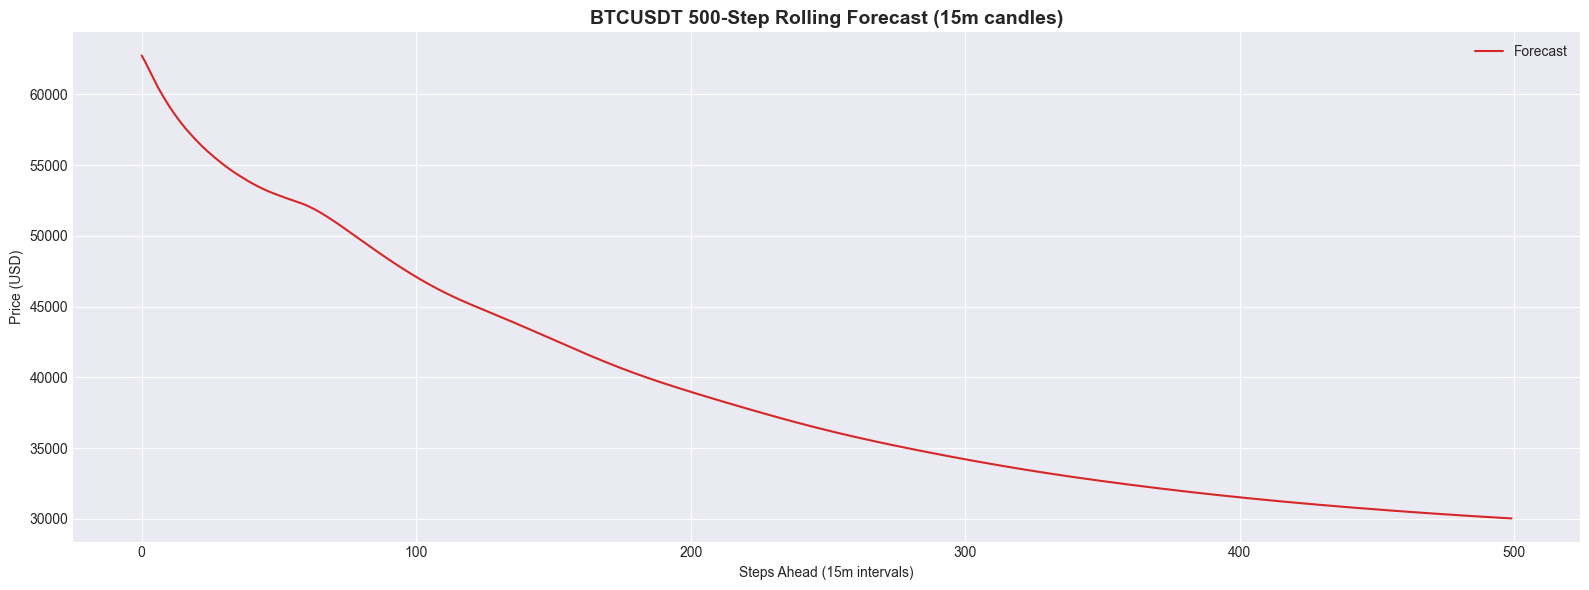

Forecast range: $30,028 - $62,747


In [34]:
FORECAST_STEPS = 500

# Seed window: last 60 scaled close values from the test set
last_window = X_test[-1]  # shape (60, 1)
forecast = forecast_future(model, last_window, steps=FORECAST_STEPS, scaler_y=close_scaler)

fig = plot_future_forecast(
    forecast,
    title=f'BTCUSDT {FORECAST_STEPS}-Step Rolling Forecast (15m candles)',
    xlabel='Steps Ahead (15m intervals)',
)
export_readme_figure(fig, 'future_forecast_500_step.png')
plt.show()

print(f'Forecast range: ${forecast.min():,.0f} - ${forecast.max():,.0f}')


### Forecast Commentary

The rolling 500-step forecast is auto-regressive: each new prediction feeds the next input window. This design naturally accumulates error over horizon.

- Short horizon (first few steps): usually most credible.
- Medium horizon: drift appears as compounding approximation noise.
- Long horizon: trajectories may flatten, overshoot, or diverge from realized market dynamics.

Interpret the reported forecast min/max range as a scenario envelope from this model setup, **not** a calibrated confidence interval. For high-frequency crypto, random-walk-like behavior and regime shifts can quickly dominate model signal, so this section is best treated as exploratory rather than decision-grade forecasting.

## 10. Model Comparison & Conclusions

In [35]:
comparison = pd.DataFrame({
    'Model': ['Bidirectional LSTM', 'MC-Dropout LSTM'],
    'RMSE (USD)': [metrics['rmse'], mc_metrics['rmse']],
    'MAE (USD)':  [metrics['mae'],  mc_metrics['mae']],
    'MAPE (%)':   [metrics['mape'], mc_metrics['mape']],
})
comparison.round(2).to_csv(README_ASSET_DIR / 'model_comparison.csv', index=False)
comparison.style.format({
    'RMSE (USD)': '${:,.2f}',
    'MAE (USD)': '${:,.2f}',
    'MAPE (%)': '{:.2f}%',
}).set_caption('Model Performance Comparison')


,Model,RMSE (USD),MAE (USD),MAPE (%)
0,Bidirectional LSTM,$991.02,$655.65,1.27%
1,MC-Dropout LSTM,$849.99,$549.38,1.13%


### Comparative Interpretation

The RMSE/MAE/MAPE table should be read as a **point-forecast accuracy comparison** between deterministic BiLSTM and stochastic MC-Dropout mean prediction.

- Lower **RMSE** indicates better handling of larger errors (penalizes outliers more strongly).
- Lower **MAE** reflects better median-like typical error behavior in USD terms.
- Lower **MAPE** is useful for relative-scale interpretation across changing BTC regimes.

Even when MC-Dropout has slightly weaker point metrics, it contributes uncertainty estimates that are operationally useful. In practice, these models serve complementary roles:

1. **Bidirectional LSTM**: strongest candidate for next-step point prediction.
2. **MC-Dropout LSTM**: risk-aware prediction via confidence bands.
3. **PPO RL Agent**: policy optimization for action-taking (buy/hold/sell), not direct point forecasting.

A robust deployment path is to combine these: use BiLSTM/MC-Dropout for directional and confidence signals, then pass risk-conditioned signals to an execution policy.

### Key Takeaways

- **Bidirectional LSTMs** effectively learn short-term temporal patterns in crypto price data, achieving low RMSE on next-step prediction.
- **MC-Dropout** adds uncertainty estimates with minimal architectural changes. Wide confidence intervals signal volatile regimes.
- **PPO-based RL** learns a viable trading policy, though performance depends on reward shaping and training duration.
- **Auto-regressive forecasts** degrade beyond a few dozen steps as errors compound.

### Limitations

- Models use only price and volume-derived features; on-chain data, sentiment, or macroeconomic indicators could improve results.
- No hyperparameter tuning was performed.
- The RL agent trains on the same data it is tested on.

### Future Work

- Transformer-based architectures (Temporal Fusion Transformer)
- Multi-asset feature correlation (ETH/BTC spread)
- Walk-forward cross-validation
- Paper-trading deployment for the RL agent

## 11. Unseen Data Validation (Out-of-Sample)

This section evaluates the already-trained LSTM models on **truly unseen BTCUSDT 15m data**.

Validation setup:
- Download the next **3 monthly files** after the last month used above.
- Run inference with both trained LSTM models.
- Compare performance across:
  - **1 week**
  - **1 month**
  - **Full 3 months**

Goal: visualize and quantify how prediction precision changes as forecast horizon extends further into unseen regimes.

In [36]:
# 11.1 Detect unseen months and build download URLs
from pathlib import Path

BASE_BTC15M = "https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/15m/BTCUSDT-15m-"

# Cutoff month from the dataset already used in this notebook
last_seen_ts = pd.to_datetime(btc_15m['open_time'].max(), unit='ms')
next_month_start = (last_seen_ts.to_period('M') + 1).to_timestamp()
unseen_months = pd.date_range(start=next_month_start, periods=3, freq='MS')

unseen_urls = [f"{BASE_BTC15M}{d.strftime('%Y-%m')}.zip" for d in unseen_months]

print(f"Last seen timestamp in training/testing source: {last_seen_ts}")
print("Unseen monthly files to download:")
for u in unseen_urls:
    print("  -", u)

Last seen timestamp in training/testing source: 2024-09-30 23:45:00
Unseen monthly files to download:
  - https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/15m/BTCUSDT-15m-2024-10.zip
  - https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/15m/BTCUSDT-15m-2024-11.zip
  - https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/15m/BTCUSDT-15m-2024-12.zip


In [37]:
# 11.2 Download and load unseen BTCUSDT 15m data

unseen_csvs = download_pair(unseen_urls, DATA_DIR, quiet=False)
unseen_raw = load_csvs(unseen_csvs, cols)

if unseen_raw.empty:
    raise ValueError("No unseen data loaded. Check Binance URLs or local download cache.")

# Match preprocessing style used earlier
unseen_btc_15m = unseen_raw.copy().sort_values('open_time').reset_index(drop=True)

drop_cols = ['quote_volume', 'close_time', 'count',
             'taker_buy_volume', 'taker_buy_quote_volume', 'ignore']
unseen_btc_15m = unseen_btc_15m.drop([c for c in drop_cols if c in unseen_btc_15m.columns], axis=1)

for col in ['open_time', 'open', 'high', 'low', 'close', 'volume']:
    unseen_btc_15m[col] = pd.to_numeric(unseen_btc_15m[col], errors='coerce')

unseen_btc_15m = unseen_btc_15m.dropna(subset=['open_time', 'close']).reset_index(drop=True)
unseen_btc_15m['datetime'] = pd.to_datetime(unseen_btc_15m['open_time'], unit='ms')

print(f"Unseen rows loaded: {len(unseen_btc_15m):,}")
print(f"Unseen range: {unseen_btc_15m['datetime'].min()} -> {unseen_btc_15m['datetime'].max()}")
unseen_btc_15m.head()

Unseen rows loaded: 8,829
Unseen range: 2024-10-01 00:15:00 -> 2024-12-31 23:45:00


,open_time,open,high,low,close,volume,datetime
0,1727741700000,63207.83,63374.00,63006.70,63350.04,406.33911,2024-10-01 00:15:00
1,1727742600000,63350.03,63426.85,63255.03,63416.00,175.10422,2024-10-01 00:30:00
2,1727743500000,63416.00,63606.00,63408.00,63531.99,265.75893,2024-10-01 00:45:00
3,1727744400000,63532.00,63639.86,63370.01,63506.25,421.97200,2024-10-01 01:00:00
4,1727745300000,63506.25,63585.64,63456.01,63568.00,192.83738,2024-10-01 01:15:00


In [39]:
# 11.3 Feature engineering + scaling alignment with training pipeline

unseen_feat = unseen_btc_15m.copy().reset_index(drop=True)

# Reuse exact indicator logic from training section
unseen_feat['RSI'] = ta.rsi(unseen_feat['close'], length=14)
macd_unseen = ta.macd(unseen_feat['close'], fast=12, slow=26, signal=9)
unseen_feat['MACD'] = macd_unseen['MACD_12_26_9']
unseen_feat['Signal_Line'] = macd_unseen['MACDs_12_26_9']
unseen_feat['SMA_10'] = ta.sma(unseen_feat['close'], length=10)
unseen_feat['SMA_50'] = ta.sma(unseen_feat['close'], length=50)

#bb_unseen = ta.bbands(unseen_feat['close'], length=20, std=2)
#unseen_feat['Upper_Band'] = bb_unseen['BBU_20_2.0']
#unseen_feat['Lower_Band'] = bb_unseen['BBL_20_2.0']

unseen_feat['ATR'] = ta.atr(unseen_feat['high'], unseen_feat['low'], unseen_feat['close'], length=14)
unseen_feat['OBV'] = ta.obv(unseen_feat['close'], unseen_feat['volume'])

stoch_unseen = ta.stoch(unseen_feat['high'], unseen_feat['low'], unseen_feat['close'], k=14, d=3)
unseen_feat['%K'] = stoch_unseen['STOCHk_14_3_3']
unseen_feat['%D'] = stoch_unseen['STOCHd_14_3_3']

# Preserve datetime for horizon slicing, then drop rows with indicator NaNs
unseen_feat = unseen_feat.dropna().reset_index(drop=True)

# Keep same feature schema as training scaler
feature_cols = list(X_train.columns)
missing_cols = [c for c in feature_cols if c not in unseen_feat.columns]
if missing_cols:
    raise ValueError(f"Unseen data missing feature columns: {missing_cols}")

unseen_X = unseen_feat[feature_cols].copy()
unseen_scaled = pd.DataFrame(scaler_X.transform(unseen_X), columns=feature_cols)

print(f"Aligned unseen feature shape: {unseen_X.shape}")
print(f"Feature columns match training schema: {feature_cols == list(unseen_X.columns)}")

Aligned unseen feature shape: (8780, 14)
Feature columns match training schema: True


In [40]:
# 11.4 Build unseen windows and run both trained LSTM models
from keras.models import load_model

LOOKBACK_UNSEEN = 60

# Build sequences exactly like inference setup above
X_unseen = []
y_unseen_close = []
dt_unseen = []

for i in range(LOOKBACK_UNSEEN, len(unseen_scaled)):
    X_unseen.append(unseen_scaled.iloc[i - LOOKBACK_UNSEEN:i, 0].values.reshape(-1, 1))
    y_unseen_close.append(unseen_feat['close'].iloc[i])
    dt_unseen.append(unseen_feat['datetime'].iloc[i])

X_unseen = np.array(X_unseen)
y_unseen_close = np.array(y_unseen_close)
dt_unseen = pd.to_datetime(pd.Series(dt_unseen)).reset_index(drop=True)

# Ensure BiLSTM model exists (use in-memory if already trained; else load from file)
if 'model' not in globals() or model is None:
    model = load_model('../models/btc15m_bilstm.keras')

# Ensure MC model exists (in-memory preferred). Try loading if file exists.
mc_available = True
if 'mc_model' not in globals() or mc_model is None:
    try:
        mc_model = load_model('../models/btc15m_mc_dropout.keras')
    except Exception:
        mc_available = False
        print("MC-Dropout model not found in memory or models/btc15m_mc_dropout.keras. "
              "Run Section 7 training first to enable MC unseen validation.")

# BiLSTM deterministic prediction
pred_unseen_scaled = model.predict(X_unseen, verbose=0)
pred_unseen_bilstm = close_scaler.inverse_transform(pred_unseen_scaled).flatten()

# MC-Dropout stochastic prediction
if mc_available:
    N_MC_SAMPLES_UNSEEN = 50
    mc_mean_scaled, mc_std_scaled = predict_with_uncertainty(mc_model, X_unseen, n_iterations=N_MC_SAMPLES_UNSEEN)
    pred_unseen_mc_mean = close_scaler.inverse_transform(mc_mean_scaled.reshape(-1, 1)).flatten()
    pred_unseen_mc_std = mc_std_scaled.flatten() * (close_scaler.data_max_[0] - close_scaler.data_min_[0])
else:
    pred_unseen_mc_mean = None
    pred_unseen_mc_std = None

unseen_pred_df = pd.DataFrame({
    'datetime': dt_unseen,
    'actual_close': y_unseen_close,
    'bilstm_pred': pred_unseen_bilstm,
})

if mc_available:
    unseen_pred_df['mc_mean_pred'] = pred_unseen_mc_mean
    unseen_pred_df['mc_std'] = pred_unseen_mc_std

print(f"Unseen inference rows: {len(unseen_pred_df):,}")
unseen_pred_df.head()

Unseen inference rows: 8,720


,datetime,actual_close,bilstm_pred,mc_mean_pred,mc_std
0,2024-10-02 03:30:00,61867.10,61145.941406,62195.552835,786.333963
1,2024-10-02 03:45:00,61750.47,61127.976562,62235.394415,961.793394
2,2024-10-02 04:00:00,61684.85,61182.105469,62425.714735,864.954540
3,2024-10-02 04:15:00,61634.00,61159.910156,62160.609335,757.905335
4,2024-10-02 04:30:00,61517.99,61103.644531,61942.913050,851.346461


In [41]:
# 11.5 Horizon-based evaluation: 1 week, 1 month, 3 months

def evaluate_horizon(df_slice, model_col):
    return evaluate_model(df_slice['actual_close'].values, df_slice[model_col].values)

start_dt = unseen_pred_df['datetime'].iloc[0]
one_week_end = start_dt + pd.Timedelta(days=7)
one_month_end = start_dt + pd.DateOffset(months=1)

horizons = {
    '1 Week': unseen_pred_df[unseen_pred_df['datetime'] < one_week_end].copy(),
    '1 Month': unseen_pred_df[unseen_pred_df['datetime'] < one_month_end].copy(),
    '3 Months': unseen_pred_df.copy(),
}

rows = []
for h_name, h_df in horizons.items():
    if len(h_df) == 0:
        continue

    m_bi = evaluate_horizon(h_df, 'bilstm_pred')
    rows.append({
        'Horizon': h_name,
        'Model': 'Bidirectional LSTM',
        'RMSE (USD)': m_bi['rmse'],
        'MAE (USD)': m_bi['mae'],
        'MAPE (%)': m_bi['mape'],
        'N': len(h_df),
    })

    if 'mc_mean_pred' in h_df.columns:
        m_mc = evaluate_horizon(h_df, 'mc_mean_pred')
        rows.append({
            'Horizon': h_name,
            'Model': 'MC-Dropout LSTM',
            'RMSE (USD)': m_mc['rmse'],
            'MAE (USD)': m_mc['mae'],
            'MAPE (%)': m_mc['mape'],
            'N': len(h_df),
        })

unseen_metrics = pd.DataFrame(rows)
if not unseen_metrics.empty:
    unseen_metrics.round(2).to_csv(README_ASSET_DIR / 'unseen_metrics.csv', index=False)
unseen_metrics


,Horizon,Model,RMSE (USD),MAE (USD),MAPE (%),N
0,1 Week,Bidirectional LSTM,723.661513,697.034726,1.123373,672
1,1 Week,MC-Dropout LSTM,424.476586,372.861726,0.602323,672
2,1 Month,Bidirectional LSTM,920.976974,881.711924,1.328769,2975
3,1 Month,MC-Dropout LSTM,364.006490,291.349223,0.447776,2975
4,3 Months,Bidirectional LSTM,4978.682874,4036.035760,4.345379,8720
5,3 Months,MC-Dropout LSTM,5306.890531,3992.452626,4.174146,8720


Saved README figure: ..\assets\readme\unseen_overlay_1_week.png


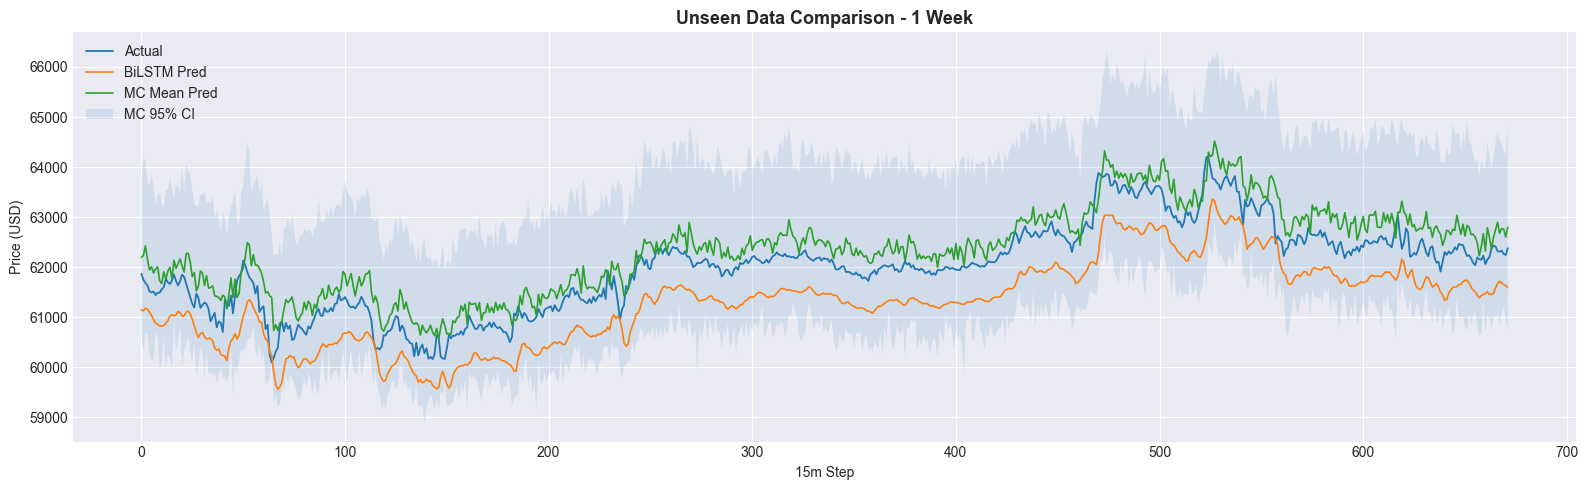

Saved README figure: ..\assets\readme\unseen_overlay_1_month.png


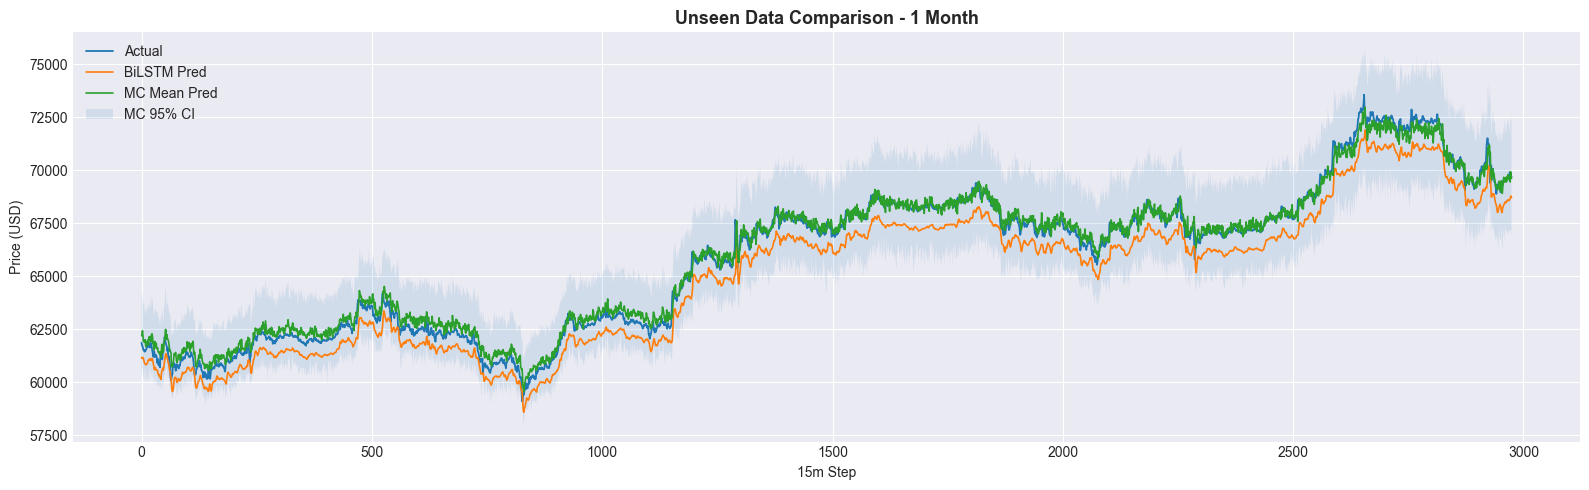

Saved README figure: ..\assets\readme\unseen_overlay_3_months.png


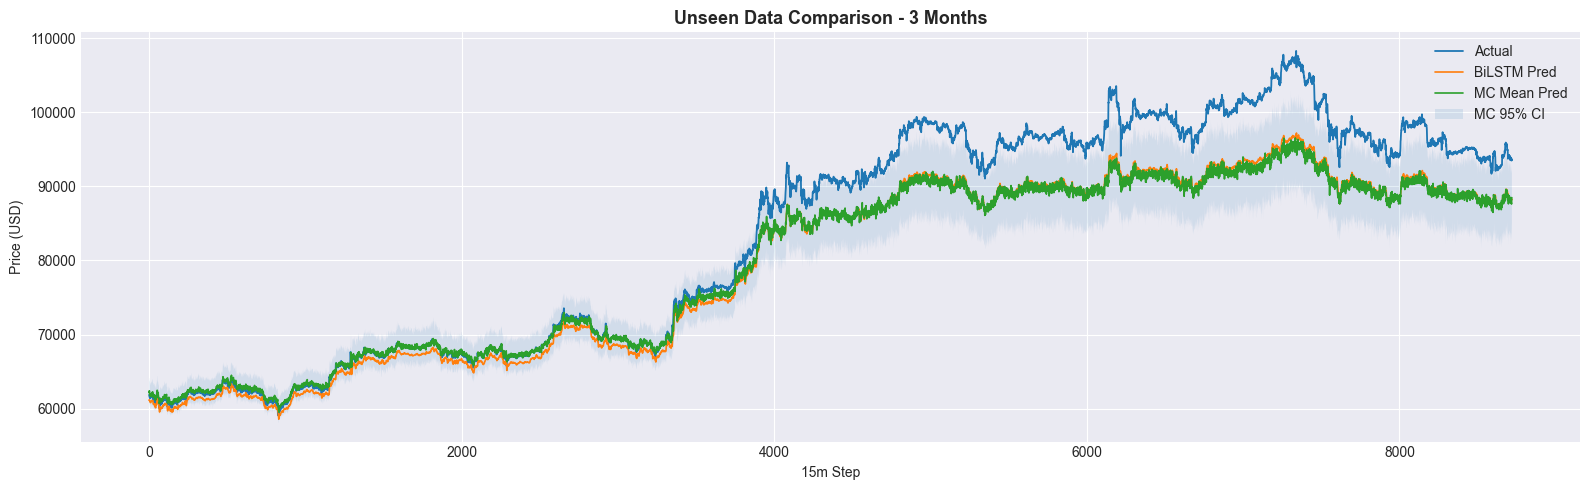

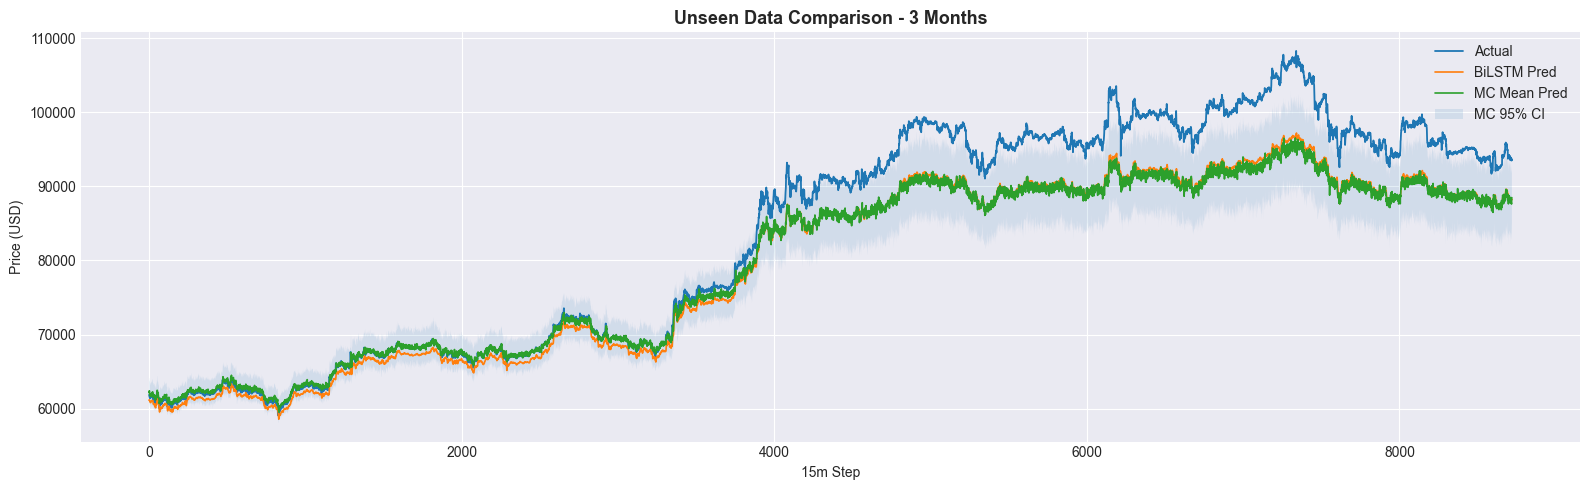

In [42]:
# 11.6 Plot overlays for each horizon (actual vs predictions)

def plot_horizon_overlay(df_slice, title_suffix, filename):
    fig, ax = plt.subplots(figsize=(16, 5))
    x = np.arange(len(df_slice))

    ax.plot(x, df_slice['actual_close'].values, label='Actual', linewidth=1.3)
    ax.plot(x, df_slice['bilstm_pred'].values, label='BiLSTM Pred', linewidth=1.2)

    if 'mc_mean_pred' in df_slice.columns:
        ax.plot(x, df_slice['mc_mean_pred'].values, label='MC Mean Pred', linewidth=1.2)
        ax.fill_between(
            x,
            df_slice['mc_mean_pred'].values - 2 * df_slice['mc_std'].values,
            df_slice['mc_mean_pred'].values + 2 * df_slice['mc_std'].values,
            alpha=0.12,
            label='MC 95% CI',
        )

    ax.set_title(f'Unseen Data Comparison - {title_suffix}', fontsize=13, fontweight='bold')
    ax.set_xlabel('15m Step')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    fig.tight_layout()
    export_readme_figure(fig, filename)
    plt.show()
    return fig

plot_horizon_overlay(horizons['1 Week'], '1 Week', 'unseen_overlay_1_week.png')
plot_horizon_overlay(horizons['1 Month'], '1 Month', 'unseen_overlay_1_month.png')
plot_horizon_overlay(horizons['3 Months'], '3 Months', 'unseen_overlay_3_months.png')


Saved README figure: ..\assets\readme\unseen_rmse_bars.png


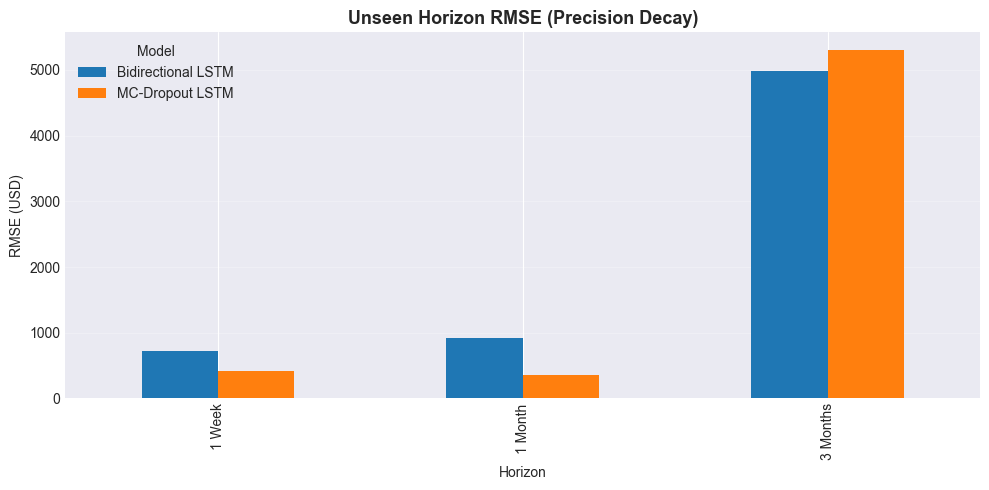

Saved README figure: ..\assets\readme\rolling_mae_unseen.png


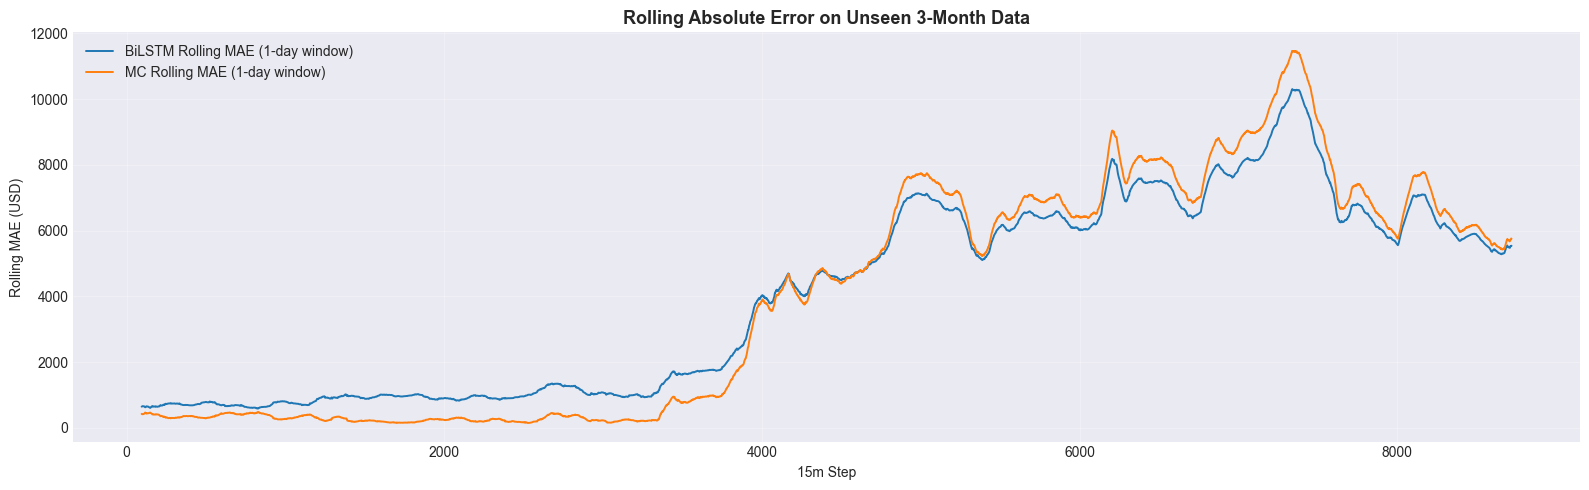

In [43]:
# 11.7 Precision decay visualization

# (A) Horizon-level RMSE bars
pivot_rmse = unseen_metrics.pivot(index='Horizon', columns='Model', values='RMSE (USD)')
pivot_rmse = pivot_rmse.reindex(['1 Week', '1 Month', '3 Months'])

fig, ax = plt.subplots(figsize=(10, 5))
pivot_rmse.plot(kind='bar', ax=ax)
ax.set_title('Unseen Horizon RMSE (Precision Decay)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (USD)')
ax.set_xlabel('Horizon')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
export_readme_figure(fig, 'unseen_rmse_bars.png')
plt.show()

# (B) Rolling MAE growth over full unseen 3-month span
rolling_window = 96  # 1 day (96 x 15m)
rolling_mae_bi = (unseen_pred_df['actual_close'] - unseen_pred_df['bilstm_pred']).abs().rolling(rolling_window).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(rolling_mae_bi.values, label='BiLSTM Rolling MAE (1-day window)', linewidth=1.4)

if 'mc_mean_pred' in unseen_pred_df.columns:
    rolling_mae_mc = (unseen_pred_df['actual_close'] - unseen_pred_df['mc_mean_pred']).abs().rolling(rolling_window).mean()
    ax.plot(rolling_mae_mc.values, label='MC Rolling MAE (1-day window)', linewidth=1.4)

ax.set_title('Rolling Absolute Error on Unseen 3-Month Data', fontsize=13, fontweight='bold')
ax.set_xlabel('15m Step')
ax.set_ylabel('Rolling MAE (USD)')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
export_readme_figure(fig, 'rolling_mae_unseen.png')
plt.show()


### Out-of-Sample Interpretation (Week -> Month -> 3 Months)

Use the horizon table and plots together to assess degradation:

- If **RMSE/MAE/MAPE increase** from 1 week to 1 month to 3 months, the model is losing calibration as market regime drift accumulates.
- In overlay plots, watch for increasing **lag and smoothing bias** during sharp directional moves.
- For MC-Dropout, widening confidence bands over longer horizons indicate reduced certainty in unfamiliar patterns.

Practical implications:

1. Treat very short-horizon unseen predictions (e.g., 1 week) as the most reliable window.
2. Consider **walk-forward retraining** (monthly or bi-weekly) to reduce regime mismatch.
3. Use uncertainty-aware filtering (skip/resize trades when MC intervals are wide).
4. Monitor rolling MAE in production as a trigger for model refresh.

This section is a true out-of-sample check and should be weighted more heavily than in-sample or near-sample validation.